# Testing
bfs_hotelbetriebe_flughafenregion_od1103
## Hotelbetriebe in der Flughafenregion
Datum: 13.12.2024

### Kurzbeschreibung
Diese Daten beinhalten Zahlen zur den Hotelbetrieben in der Flughafenregion.

Dataset auf PROD-Datakatalog: Link https://data.stadt-zuerich.ch/dataset/bfs_hotelbetriebe_flughafenregion_od1103

Dataset auf INTEG-Datakatalog: Link https://data.integ.stadt-zuerich.ch/dataset/int_dwh_bfs_hotelbetriebe_flughafenregion_od1103

### Importiere die notwendigen Packages

In [1]:
#%pip install altair folium geopandas matplotlib numpy pandas plotly requests seaborn

In [2]:
import altair as alt
import datetime
import folium 
import geopandas as gpd
import io
from IPython.display import Markdown as md
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
#import pivottablejs
#from pivottablejs import pivot_ui
import plotly.express as px
import requests
import seaborn as sns

Importiere die eigenen Funktionen, die unter ../0_scripts abegelegt sind:

In [3]:
import sys
sys.path.append('../0_scripts')

import my_py_dataviz_functions as mypy_dv
import my_py_dataloading_functions as mypy_dl

In [4]:
SSL_VERIFY = False
# evtl. SSL_VERIFY auf False setzen wenn die Verbindung zu https://www.gemeinderat-zuerich.ch nicht klappt (z.B. wegen Proxy)
# Um die SSL Verifikation auszustellen, bitte die nächste Zeile einkommentieren ("#" entfernen)
# SSL_VERIFY = False

In [5]:
if not SSL_VERIFY:
    import urllib3
    urllib3.disable_warnings()

### Settings
Definiere Settings. 
Hier das Zahlenformat von Float-Werten (z.B. *'{:,.2f}'.format* mit Komma als Tausenderzeichen)

In [6]:
#pd.options.display.float_format = lambda x : '{:,.1f}'.format(x) if (np.isnan(x) | np.isinf(x)) else '{:,.0f}'.format(x) if int(x) == x else '{:,.1f}'.format(x)
pd.options.display.float_format = '{:.0f}'.format
pd.set_option('display.width', 100)
pd.set_option('display.max_columns', 15)

#### Zeitvariabeln


In [7]:
#Zeitvariabeln als Strings:
now = datetime.date.today()
year_today = now.strftime("%Y")
date_today = "_"+now.strftime("%Y-%m-%d")

#Zeitvariabeln als Integers:
int_times = now.timetuple()
aktuellesJahr = int_times[0]
aktuellerMonat = int_times[1]
selectedMonat = int_times[1]-2
#print(aktuellesJahr, aktuellerMonat,'datenstand: ', selectedMonat, int_times)

### Daten importieren und Metadaten checken

- status: int / prod
- data_source: web / ld / dropzone
- datums_attr: beschreibt das oder die Datumsfelder, die als Datum geparsed werden sollen. Falls es keines gibt: None

In [8]:
package_name = "bfs_hotelbetriebe_flughafenregion_od1103"

In [9]:
#help(mypy_dl.load_data)

In [10]:
data2betested = mypy_dl.load_data(
    status = 'int'
    , data_source = 'web'
    , package_name = package_name
    , dataset_name = "WIR110OD1103"    
    , datums_attr = ['StichtagDatMMYY']
    , na_values= ['K']
    )

fp lautet:https://data.integ.stadt-zuerich.ch/dataset/int_dwh_bfs_hotelbetriebe_flughafenregion_od1103/download/WIR110OD1103.csv


 **Überprüfe die Metadaten:**

 **Dataset auf INTEG-Datakatalog:** Link https://data.integ.stadt-zuerich.ch/dataset/int_dwh_bfs_hotelbetriebe_flughafenregion_od1103 

 **Dataset auf PROD-Datakatalog:** Link https://data.stadt-zuerich.ch/dataset/bfs_hotelbetriebe_flughafenregion_od1103 

data_source: web


In [11]:
data2betested.tail(2).T

,1998,1999
StichtagDatMMYY,2025-09-01 00:00:00,2025-10-01 00:00:00
Kennzahl,Zimmerbelegung (in %),Zimmerbelegung (in %)
Anzahl,77,70


In [12]:
data2betested.dtypes

StichtagDatMMYY    datetime64[ns]
Kennzahl                   object
Anzahl                    float64
dtype: object

In [13]:
data2betested['Anzahl'].sort_values(ascending=False)

1484   190177
1497   188495
1496   186652
1495   184701
1483   182300
        ...  
337         1
334         1
333         1
280         1
417         1
Name: Anzahl, Length: 2000, dtype: float64

In [14]:
data2betested.columns

Index(['StichtagDatMMYY', 'Kennzahl', 'Anzahl'], dtype='object')

Berechne weitere Attribute falls notwendig

In [15]:
data2betested = (
    data2betested
    .copy()
    .assign(
        #Aktualisierungs_Datum_str= lambda x: x.Aktualisierungs_Datum.astype(str),
        #StichtagDat_str = lambda x: x.StichtagDat.astype(str),
        Jahr_Monat = lambda x: x.StichtagDatMMYY,
        Jahr_nbr = lambda x: x.Jahr_Monat.dt.year,
        Jahr_Monat_end = lambda x: x.StichtagDatMMYY+pd.offsets.MonthEnd(0),
        #Jahr_Monat_str = lambda x: x.StichtagDatMMYY.astype(str).str.zfill(2),
        Jahr_Monat_str = lambda x: x.Jahr_Monat_end.astype(str),
    
    )
    .sort_values('StichtagDatMMYY', ascending=False)
    )
data2betested.dtypes

StichtagDatMMYY    datetime64[ns]
Kennzahl                   object
Anzahl                    float64
Jahr_Monat         datetime64[ns]
Jahr_nbr                    int32
Jahr_Monat_end     datetime64[ns]
Jahr_Monat_str             object
dtype: object

In [16]:
data2betested.head(2).T

,1999,999
StichtagDatMMYY,2025-10-01 00:00:00,2025-10-01 00:00:00
Kennzahl,Zimmerbelegung (in %),Betten
Anzahl,70,10455
Jahr_Monat,2025-10-01 00:00:00,2025-10-01 00:00:00
Jahr_nbr,2025,2025
Jahr_Monat_end,2025-10-31 00:00:00,2025-10-31 00:00:00
Jahr_Monat_str,2025-10-31,2025-10-31


Minimales und maximales Jahr im Datensatz

In [17]:

data_max_date = max(data2betested.Jahr_Monat_end).strftime('%Y-%m-%d')#.strftime('%Y-%m-%d')
data_min_date = min(data2betested.Jahr_Monat_end).strftime('%Y-%m-%d')

print(f"Die Daten haben ein Minimumjahr von {data_min_date} und ein Maximumjahr von {data_max_date}")

Die Daten haben ein Minimumjahr von 2005-01-31 und ein Maximumjahr von 2025-10-31


### Einfache Datentests

In [18]:
data2betested.sort_values('Jahr_Monat_str', ascending=False).head(2).T

,1999,1749
StichtagDatMMYY,2025-10-01 00:00:00,2025-10-01 00:00:00
Kennzahl,Zimmerbelegung (in %),Zimmer
Anzahl,70,5325
Jahr_Monat,2025-10-01 00:00:00,2025-10-01 00:00:00
Jahr_nbr,2025,2025
Jahr_Monat_end,2025-10-31 00:00:00,2025-10-31 00:00:00
Jahr_Monat_str,2025-10-31,2025-10-31


In [19]:
#data2betested.dtypes
data2betested.info(memory_usage='deep', verbose=True)

<class 'pandas.core.frame.DataFrame'>
Index: 2000 entries, 1999 to 1000
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   StichtagDatMMYY  2000 non-null   datetime64[ns]
 1   Kennzahl         2000 non-null   object        
 2   Anzahl           2000 non-null   float64       
 3   Jahr_Monat       2000 non-null   datetime64[ns]
 4   Jahr_nbr         2000 non-null   int32         
 5   Jahr_Monat_end   2000 non-null   datetime64[ns]
 6   Jahr_Monat_str   2000 non-null   object        
dtypes: datetime64[ns](3), float64(1), int32(1), object(2)
memory usage: 366.7 KB


In [20]:
print(f'The dataset has {data2betested.shape[0]:,.0f} rows (observations) and {data2betested.shape[1]:,.0f} columns (variables).')
print(f'There seem to be {data2betested.duplicated().sum()} exact duplicates in the data.')

The dataset has 2,000 rows (observations) and 7 columns (variables).
There seem to be 0 exact duplicates in the data.


In [21]:
data2betested.describe()

,StichtagDatMMYY,Anzahl,Jahr_Monat,Jahr_nbr,Jahr_Monat_end
count,2000,2000,2000,2000,2000
mean,2015-05-17 09:36:00,20538,2015-05-17 09:36:00,2015,2015-06-15 20:03:50.400000
min,2005-01-01 00:00:00,1,2005-01-01 00:00:00,2005,2005-01-31 00:00:00
25%,2010-03-01 00:00:00,33,2010-03-01 00:00:00,2010,2010-03-31 00:00:00
50%,2015-05-16 12:00:00,953,2015-05-16 12:00:00,2015,2015-06-15 00:00:00
75%,2020-08-01 00:00:00,10459,2020-08-01 00:00:00,2020,2020-08-31 00:00:00
max,2025-10-01 00:00:00,190177,2025-10-01 00:00:00,2025,2025-10-31 00:00:00
std,NaN,37466,NaN,6,NaN


Wo gibt es fehlende Werte?

In [22]:
data2betested[np.isnan(data2betested.Anzahl)]

,StichtagDatMMYY,Kennzahl,Anzahl,Jahr_Monat,Jahr_nbr,Jahr_Monat_end,Jahr_Monat_str


### Verwende das Datum als Index

While we did already parse the `datetime` column into the respective datetime type, it currently is just a regular column. 
**To enable quick and convenient queries and aggregations, we need to turn it into the index of the DataFrame**

In [23]:
data2betested = data2betested.set_index("Jahr_Monat_end")
data2betested = data2betested.sort_index()

In [24]:
data2betested.index.year.unique()

Index([2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019,
       2020, 2021, 2022, 2023, 2024, 2025],
      dtype='int32', name='Jahr_Monat_end')

### Beschreibe einzelne Attribute

Beschreibe nicht numerische Attribute

In [25]:
# describe non-numerical features
try:
    with pd.option_context('display.float_format', '{:,.2f}'.format):
        display(data2betested.describe(exclude='number',datetime_is_numeric=True))
except:
    print("No categorical data in dataset.")

No categorical data in dataset.


Beschreibe numerische Attribute

In [26]:
# describe numerical features
try:
    with pd.option_context('display.float_format', '{:,.0f}'.format):
        display(data2betested.describe(include='number'))
except:
    print("No numercial data in dataset.")

,Anzahl,Jahr_nbr
count,"2,000","2,000"
mean,"20,538","2,015"
std,"37,466",6
min,1,"2,005"
25%,33,"2,010"
50%,953,"2,015"
75%,"10,459","2,020"
max,"190,177","2,025"


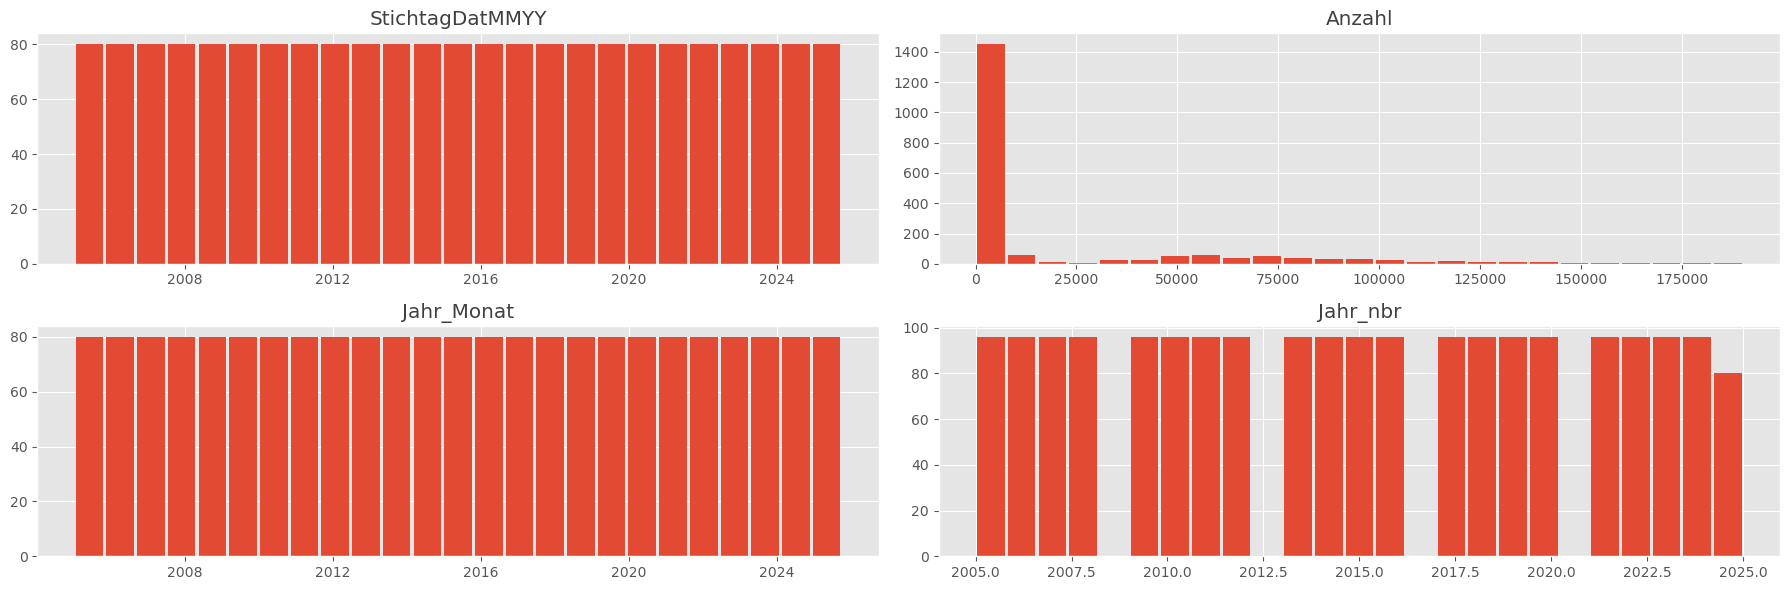

In [27]:
plt.style.use('ggplot')
params = {
    'text.color': (0.25, 0.25, 0.25),
    'figure.figsize': [18, 6],
   }
plt.rcParams.update(params)

try:
    data2betested.hist(bins=25, rwidth=0.9)
    plt.tight_layout()
    plt.show()
except:
    print("No numercial data to plot.") 

### Gibt es Duplikate?

In [28]:
# find duplicate rows
duplicate_rows = data2betested[data2betested.duplicated()]
duplicate_rows

,StichtagDatMMYY,Kennzahl,Anzahl,Jahr_Monat,Jahr_nbr,Jahr_Monat_str
Jahr_Monat_end,,,,,,


### Nullwerte und Missings?

In [29]:
data2betested.isnull().sum()

StichtagDatMMYY    0
Kennzahl           0
Anzahl             0
Jahr_Monat         0
Jahr_nbr           0
Jahr_Monat_str     0
dtype: int64

In [30]:
# check missing values with missingno
# https://github.com/ResidentMario/missingno
#import missingno as msno
#msno.matrix(data2betested, labels=True, sort='descending');
#msno.heatmap(data2betested)

### Gruppierungen

In [31]:
data2betested.reset_index().columns

Index(['Jahr_Monat_end', 'StichtagDatMMYY', 'Kennzahl', 'Anzahl', 'Jahr_Monat', 'Jahr_nbr',
       'Jahr_Monat_str'],
      dtype='object')

In [32]:
agg_jahr = data2betested.loc[data_min_date:data_max_date].reset_index()\
    .groupby(['StichtagDatMMYY', 'Jahr_Monat_end','Jahr_Monat', 'Jahr_nbr','Jahr_Monat_str']) \
    .agg(sum_Anz=('Anzahl', 'sum')) \
    .sort_values('Jahr_Monat_end', ascending=False) 
agg_jahr.reset_index().head(6)

,StichtagDatMMYY,Jahr_Monat_end,Jahr_Monat,Jahr_nbr,Jahr_Monat_str,sum_Anz
0,2025-10-01,2025-10-31,2025-10-01,2025,2025-10-31,290952
1,2025-09-01,2025-09-30,2025-09-01,2025,2025-09-30,308385
2,2025-08-01,2025-08-31,2025-08-01,2025,2025-08-31,334945
3,2025-07-01,2025-07-31,2025-07-01,2025,2025-07-31,332327
4,2025-06-01,2025-06-30,2025-06-01,2025,2025-06-30,328936
5,2025-05-01,2025-05-31,2025-05-01,2025,2025-05-31,315935


In [33]:
agg_kennzahl = data2betested.loc[data_min_date:data_max_date]\
    .groupby(['Kennzahl']) \
    .agg(sum_Anz=('Anzahl', 'sum')) \
    .sort_values('Kennzahl', ascending=False) 
agg_kennzahl.reset_index().head(6)

,Kennzahl,sum_Anz
0,Zimmerbelegung (in %),16439
1,Zimmer,842847
2,Logiernächte,23149725
3,Bettenbesetzung (in %),13528
4,Betten,1445887
5,Betriebe,6837


### Visualisierungen nach Zeitausschnitten

In [34]:
data2betested.info()
#data2betested

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2000 entries, 2005-01-31 to 2025-10-31
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   StichtagDatMMYY  2000 non-null   datetime64[ns]
 1   Kennzahl         2000 non-null   object        
 2   Anzahl           2000 non-null   float64       
 3   Jahr_Monat       2000 non-null   datetime64[ns]
 4   Jahr_nbr         2000 non-null   int32         
 5   Jahr_Monat_str   2000 non-null   object        
dtypes: datetime64[ns](2), float64(1), int32(1), object(2)
memory usage: 166.1+ KB


In [35]:
data2betested.columns

Index(['StichtagDatMMYY', 'Kennzahl', 'Anzahl', 'Jahr_Monat', 'Jahr_nbr', 'Jahr_Monat_str'], dtype='object')

#### Entwicklung der Logiernächte nach Sternen

In [36]:
grafik1 = mypy_dv.plot_altair_multiline_highlight(
    data = data2betested.reset_index().query('Kennzahl != "Logiernächterrr"')
    ,x = 'Jahr_Monat_str:T'
    ,y = 'Anzahl:Q'
    ,x_beschriftung = 'Jahr'
    , y_beschriftung = ''
    ,category = "Kennzahl:N"
    ,category_beschriftung= 'Legende:'
    ,warning_status = "ignore" #always or ignore
    ,myTitle="Entwicklung der Kennzahlen nach Monat in der Flughafenregion, seit "+data_min_date
)
grafik1

alt.LayerChart(...)

#### Entwicklung der Betten und Zimmer

In [37]:
grafik2 = mypy_dv.plot_altair_multiline_highlight(
    data = data2betested.reset_index().query('Kennzahl == "Betten" or Kennzahl == "Zimmer" ')
    ,x = 'Jahr_Monat_str:T'
    ,y = 'Anzahl:Q'
    ,x_beschriftung = 'Jahr'
    , y_beschriftung = ''
    ,category = "Kennzahl:N"
    ,category_beschriftung= 'Legende:'
    ,warning_status = "ignore" #always or ignore
    ,myTitle="Entwicklung der Betten und Zimmer nach Monat in der Flughafenregion, seit "+data_min_date
)
grafik2

alt.LayerChart(...)

#### Entwicklung der Betriebe nach Sternen

In [38]:
grafik3 = mypy_dv.plot_altair_multiline_highlight(
    data = data2betested.reset_index().query('Kennzahl == "Aufenthaltsdauer (in Tagen)" ')
    ,x = 'Jahr_Monat_str:T'
    ,y = 'Anzahl:Q'
    ,x_beschriftung = 'Jahr'
    , y_beschriftung = 'Aufenthaltsdauer'
    ,category = "Kennzahl:N"
    ,category_beschriftung= 'Legende:'
    ,warning_status = "ignore" #always or ignore
    ,myTitle="Entwicklung der Aufenthaltsdauer nach Monat in der Flughafenregion, seit "+data_min_date
)
grafik3

alt.LayerChart(...)

#### Entwicklung der Bettenbesetzung und Zimmerbelegung

In [39]:
grafik4 = mypy_dv.plot_altair_multiline_highlight(
    data = data2betested.reset_index().query('Kennzahl == "Zimmerbelegung (in %)" or Kennzahl == "Bettenbesetzung (in %)" ')
    ,x = 'Jahr_Monat_str:T'
    ,y = 'Anzahl:Q'
    ,x_beschriftung = 'Jahr'
    , y_beschriftung = ''
    ,category = "Kennzahl:N"
    ,category_beschriftung= 'Legende:'
    ,warning_status = "ignore" #always or ignore
    ,myTitle="Entwicklung der Bettenbesetzung und Zimmerbelegung nach Monat in der Flughafenregion, seit "+data_min_date
)
grafik4

alt.LayerChart(...)

#### Faced Grids

In [40]:
sns.set_theme(style="whitegrid")

In [41]:
data2betested.columns

Index(['StichtagDatMMYY', 'Kennzahl', 'Anzahl', 'Jahr_Monat', 'Jahr_nbr', 'Jahr_Monat_str'], dtype='object')

In [42]:
##.query('Kennzahl != "Logiernächte" and Kennzahl != "Ankünfte"') \
# .query('Kennzahl == "Logiernächte" or Kennzahl == "Ankünfte"') \
# .query('Kennzahl == "Betriebe"') \

myFG = data2betested\
    .groupby(['Jahr_nbr', 'Jahr_Monat_str','Kennzahl', ]) \
    .agg(sum_Anz=('Anzahl', 'sum')) \
    .sort_values('Kennzahl', ascending=False) 
myFG.reset_index().head(2)

,Jahr_nbr,Jahr_Monat_str,Kennzahl,sum_Anz
0,2025,2025-10-31,Zimmerbelegung (in %),70
1,2021,2021-06-30,Zimmerbelegung (in %),21


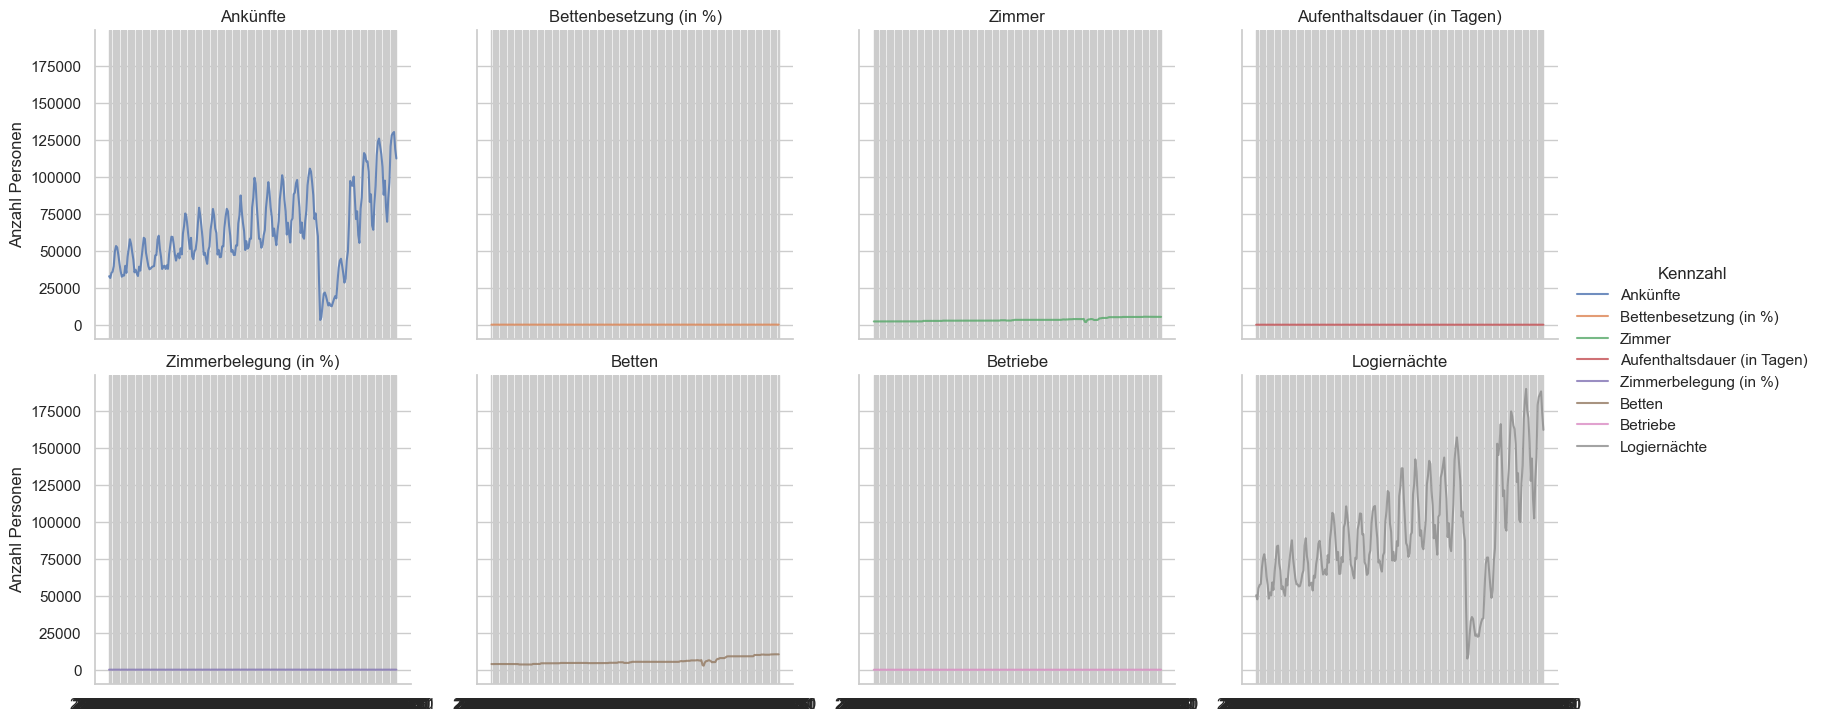

In [43]:
faced_grid1 = mypy_dv.plot_sns_facetgrid(
    data = myFG.reset_index().sort_values('Jahr_Monat_str', ascending=True)
    ,col = "Kennzahl"
    ,hue = "Kennzahl"
    ,col_wrap = 4
    ,grafiktyp = sns.lineplot
    ,x = "Jahr_Monat_str"
    ,y = "sum_Anz"
    ,ylabel= "Anzahl Personen"
    ,warning_status ="ignore"
    ,height = 3
    #,myTitle="Wohnbevölkerung nach Altersgruppe und Stadtquartier, seit "+str(int(data2betested.index.year.min()))   
)
faced_grid1

##### Gibt es zeitliche Datenlücken?

In [44]:
#Gibt es eine zeitliche Datenlücke?

timefilter = "2024"
#lücke in der zeitreihe?
ideal_time_range = pd.date_range(start=data2betested.loc[timefilter].index.min(), end=data2betested.loc[timefilter].index.max(), freq='1m') #10h

# Überprüfe, ob es Unterschiede zwischen dem idealen Zeitstempelbereich und dem tatsächlichen Index gibt
missing_timestamps_my = ideal_time_range.difference(data2betested.index)

if missing_timestamps_my.empty:
    print("Keine Lücken in der Zeitreihe gefunden.")
else:
    print("Lücken in der Zeitreihe gefunden:")
    print(missing_timestamps_my)

Keine Lücken in der Zeitreihe gefunden.


### Daten in interaktiver Treemap zeigen
Dazu gibt es eine sehr nützliche Webseite https://plotly.com/python/treemaps/
Zu Farbskalen, siehe: https://plotly.com/python/builtin-colorscales/

**Funktion zum einfärben**

Muss ich noch als Funktion umsetzen 

In [45]:
qual12br = ["#5D4BFE", "#4AA9FF", "#55FFFF", "#986AD5", "#FC4C99", "#FF919A", "#349894", "#44B14A", "#B7E14E", "#B97624", "#FF7231", "#FFD736"]
qual12 = ["#3431DE", "#0A8DF6", "#23C3F1", "#7B4FB7", "#DB247D", "#FB737E", "#007C78", "#1F9E31", "#99C32E", "#9A5B01", "#FF720C", "#FBB900"]
qual12da = ["#0017BF", "#0072D7", "#00A5D2", "#5E359A", "#BA0062", "#DA5563", "#00615D", "#00770F", "#7BA600", "#7B4100", "#DC5500", "#DA9C00"]
div9val = ["#782600", "#CC4309", "#FF720C", "#FFBC88", "#E4E0DF", "#AECBFF", "#6B8EFF", "#3B51FF", "#2F2ABB",]
div9ntr = ["#A30059", "#DB247D", "#FF579E", "#FFA8D0", "#E4E0DF", "#A8DBB1", "#55BC5D", "#1F9E31", "#10652A",]

In [46]:
# Extrahiere die Top-Fahrzeugmarken
color_var = data2betested['Kennzahl'].unique().tolist()
# Verfügbare Farben
verfügbare_farben_zuericolors = qual12da+qual12br+qual12+div9ntr

# Erstelle das Farben-Dictionary
farben_dict_zc = {'(?)':'lightgrey'}
for index, x in enumerate(color_var):
    farben_dict_zc[x] = verfügbare_farben_zuericolors[index % len(verfügbare_farben_zuericolors)]

# Das resultierende Farben-Dictionary
print(farben_dict_zc)
#print(verfügbare_farben_zuericolors)

{'(?)': 'lightgrey', 'Bettenbesetzung (in %)': '#0017BF', 'Ankünfte': '#0072D7', 'Zimmerbelegung (in %)': '#00A5D2', 'Zimmer': '#5E359A', 'Aufenthaltsdauer (in Tagen)': '#BA0062', 'Betten': '#DA5563', 'Betriebe': '#00615D', 'Logiernächte': '#00770F'}


#### Hotelbetriebe nach Kennzahl und Sternen

In [47]:
data2betested.reset_index().columns

Index(['Jahr_Monat_end', 'StichtagDatMMYY', 'Kennzahl', 'Anzahl', 'Jahr_Monat', 'Jahr_nbr',
       'Jahr_Monat_str'],
      dtype='object')

In [48]:
myTreemapAgg = data2betested.loc["2020":data_max_date]  \
    .groupby(['StichtagDatMMYY', 'Kennzahl','Jahr_Monat','Jahr_nbr', 'Jahr_Monat_str' ]) \
    .agg(sum_Anz=('Anzahl', 'sum')) \
    .sort_values('Jahr_Monat_str', ascending=False) 

myTreemapAgg.reset_index().head(4)

#.query("KreisLang ='Unbekannt'")\


,StichtagDatMMYY,Kennzahl,Jahr_Monat,Jahr_nbr,Jahr_Monat_str,sum_Anz
0,2025-10-01,Zimmerbelegung (in %),2025-10-01,2025,2025-10-31,70
1,2025-10-01,Zimmer,2025-10-01,2025,2025-10-31,5325
2,2025-10-01,Logiernächte,2025-10-01,2025,2025-10-31,162446
3,2025-10-01,Bettenbesetzung (in %),2025-10-01,2025,2025-10-31,50


In [49]:
treeMap1 = mypy_dv.plot_px_treemap(
    data=myTreemapAgg.reset_index().query('Kennzahl !="Logiernächte rrrrrrrrrr"') \
    ,levels=['Jahr_nbr','Kennzahl', ]
    ,values="sum_Anz"
    ,color="Kennzahl"
    #, color_continuous_scale='Blues'
    ,color_discrete_map=farben_dict_zc
    #,color_discrete_map={'(?)':'lightgrey', 'Erwerbstätige':'#99C32E', 'Nichterwerbspersonen':'#7B4100', 'Erwerbslose':'#DB247D'}  
    ,height=600
    ,width=1100               
    #,margin_val_bottom=25
    ,myHeaderTitle="Logiernächte nach Sternen, "+ data_min_date + " bis "+data_max_date

)
treeMap1

path: [<plotly.express._special_inputs.Constant object at 0x000001BE448B6B10>, 'Jahr_nbr', 'Kennzahl']
Typ von path: <class 'list'>


**Sharepoint als gecheckt markieren!**

Record auf Sharepoint: **[Link](https://szhglobal.sharepoint.com/sites/ssz-spo-produkte/Lists/SASA_Outputs/DispForm.aspx?ID=1279&e=WJ3yPK)**